In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
data = fetch_california_housing(as_frame=True)
df=data.frame
print("Dataset.shape ",df.shape)
df.head()

Dataset.shape  (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [70]:
X=df[["AveBedrms"]]
y=df["MedHouseVal"]
print("Input feature")
display(X.head())
print("target variable")
display(y.head())

Input feature


,AveBedrms
0,1.023810
1,0.971880
2,1.073446
3,1.073059
4,1.081081


target variable


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [71]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("training samples:", len(X_train))
print("testing samples:" , len(X_test))

training samples: 16512
testing samples: 4128


In [72]:
model=LinearRegression()
model.fit(X_train, y_train)

print("intercept:", round(model.intercept_, 4))
print("slope: ", round(model.coef_[0], 4))
print(f"\nhouse price={model.intercept_:.4f}+{model.coef_[0]:.4f}*Average Rooms")

intercept: 2.2223
slope:  -0.1371

house price=2.2223+-0.1371*Average Rooms


In [73]:
y_pred=model.predict(X_test)
print(y_pred[:10])
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("mean squared error",round(mse,4))
print("r2 score",round(r2,4))

[2.08214377 2.05867905 2.05972281 2.08242913 2.08135527 2.08861201
 2.07217474 2.07857449 2.0802696  2.08358073]
mean squared error 1.3109
r2 score -0.0004


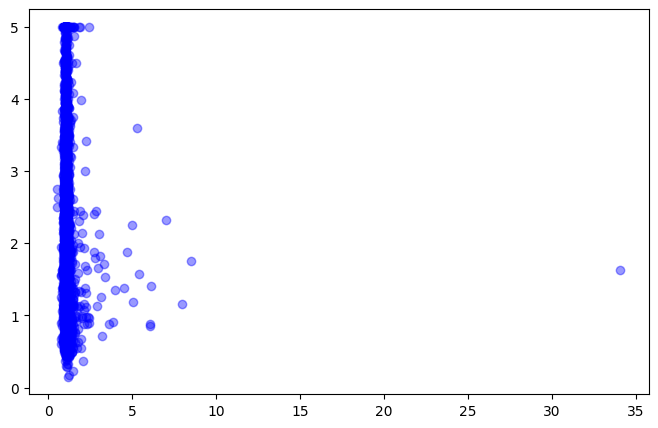

In [74]:
plt.figure(figsize=(8,5))
plt.scatter(
    X_test,
    y_test,
    color="blue",
    alpha=0.4,
    label="actual data")


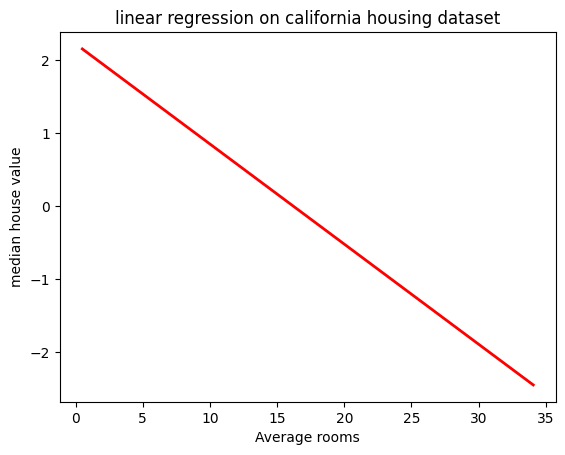

In [76]:
X_sorted=X_test.sort_values("AveRooms")
plt.plot(
    X_sorted,
    model.predict(X_sorted),
    color="red",
    linewidth=2,
    label="regression line"
)
plt.xlabel("Average rooms")
plt.ylabel("median house value")
plt.title("linear regression on california housing dataset")
plt.show()